# Task 4 - Image Segmentation Using Clustering Methods

In [1]:
import os
import json
import random
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import normalize

random.seed(42)
np.random.seed(42)

## 1. Dataset Loading

In [2]:
data_dir = "football-player-segmentation"
images_dir = os.path.join(data_dir, "images")
annotations_path = os.path.join(data_dir, "annotations", "instances_default.json")

with open(annotations_path) as f:
    coco = json.load(f)

all_file_names = [im["file_name"] for im in coco["images"]]
sample_images_names = random.sample(all_file_names, 50)

scale = 1/8

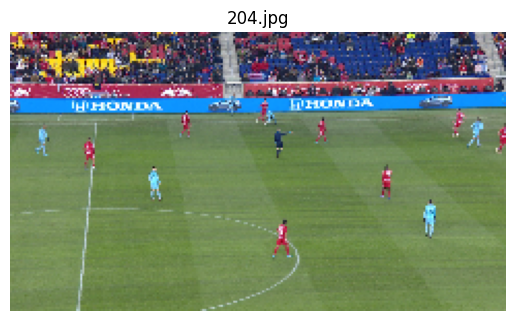

In [3]:
def load_and_scale(file_name, scale):
    img = cv2.imread(os.path.join(images_dir, file_name))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    new_w = int(img.shape[1] * scale)
    new_h = int(img.shape[0] * scale)
    img = cv2.resize(img, (new_w, new_h))
    return img

images = [load_and_scale(name, scale) for name in sample_images_names]

plt.imshow(images[0])
plt.title(sample_images_names[0])
plt.axis("off")
plt.show()

## 2. Creating Features

In [4]:
def color_features(img):
    features = img.reshape(-1, 3).astype(np.float32)
    features = features / 255.0
    return features

def color_position_features(img):
    h, w, _ = img.shape
    yy, xx = np.mgrid[0:h, 0:w]
    colors = img.reshape(-1, 3).astype(np.float32) / 255.0
    positions = np.stack([xx.flatten(), yy.flatten()], axis=1).astype(np.float32)
    positions = positions / np.array([w, h], dtype=np.float32)
    features = np.concatenate([colors, positions], axis=1)
    return features

def color_position_texture_features(img):
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    sobelx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
    sobely = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
    texture = np.sqrt(sobelx ** 2 + sobely ** 2)
    texture = texture / (texture.max() + 1e-6)
    base = color_position_features(img)
    features = np.concatenate([base, texture.reshape(-1, 1)], axis=1)
    return features

In [5]:
def evaluate_features(img, feature_fn, k=5, sample_size=2000):
    features = feature_fn(img)
    idx = np.random.choice(len(features), sample_size, replace=False)
    sample = features[idx]
    labels = KMeans(n_clusters=k, n_init=5, random_state=42).fit_predict(sample)
    score = silhouette_score(sample, labels)
    return score

test_img = images[0]
print("color only:", evaluate_features(test_img, color_features))
print("color + position:", evaluate_features(test_img, color_position_features))
print("color + position + texture:", evaluate_features(test_img, color_position_texture_features))

color only: 0.6877195835113525
color + position: 0.3147372305393219
color + position + texture: 0.3185504081702569


## 3. Cluster Pixels

In [6]:
def kmeans_segment(img, k):
    features = color_features(img)
    labels = KMeans(n_clusters=k, n_init=10, random_state=42).fit_predict(features)
    label_map = labels.reshape(img.shape[0], img.shape[1])
    return label_map

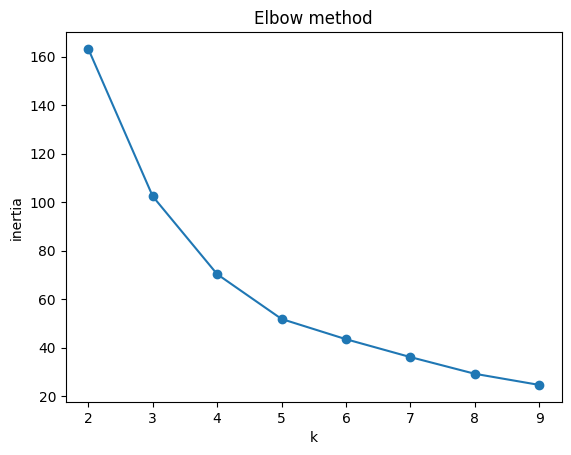

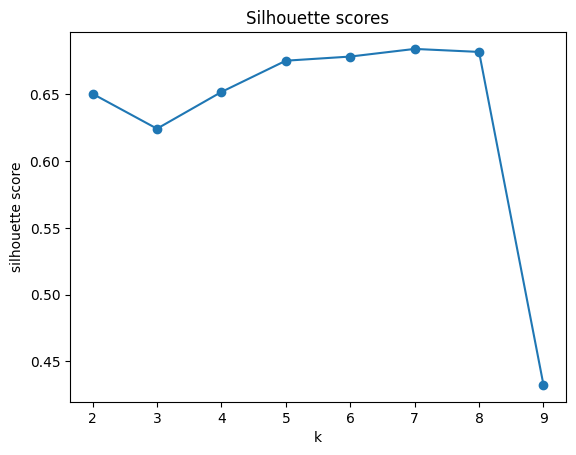

In [7]:
features = color_features(images[0])
idx = np.random.choice(len(features), 3000, replace=False)
sample = features[idx]

ks = range(2, 10)
inertias = []
silhouettes = []

for k in ks:
    km = KMeans(n_clusters=k, n_init=5, random_state=42).fit(sample)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(sample, km.labels_))

plt.plot(list(ks), inertias, marker="o")
plt.xlabel("k")
plt.ylabel("inertia")
plt.title("Elbow method")
plt.show()

plt.plot(list(ks), silhouettes, marker="o")
plt.xlabel("k")
plt.ylabel("silhouette score")
plt.title("Silhouette scores")
plt.show()

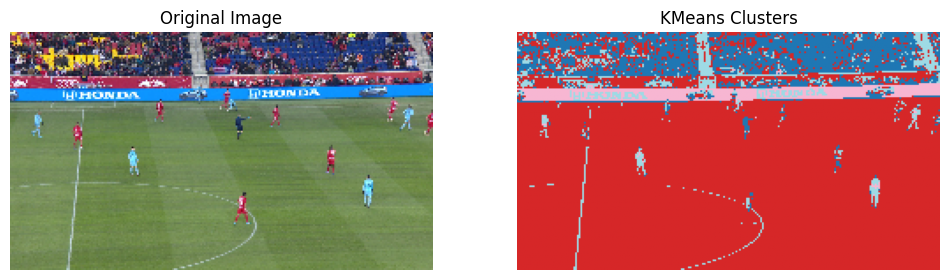

In [8]:
best_k = 4
label_map = kmeans_segment(images[0], best_k)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(images[0])
plt.title("Original Image")
plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(label_map, cmap="tab20")
plt.title("KMeans Clusters")
plt.axis("off")
plt.show()

In [9]:
db = DBSCAN(eps=0.06, min_samples=10).fit(sample)
print("DBSCAN found", len(set(db.labels_)) - (1 if -1 in db.labels_ else 0), "clusters and",
      list(db.labels_).count(-1), "noise points")

agg = AgglomerativeClustering(n_clusters=best_k).fit(sample)
print("Agglomerative silhouette score:", silhouette_score(sample, agg.labels_))

DBSCAN found 7 clusters and 311 noise points
Agglomerative silhouette score: 0.642874002456665


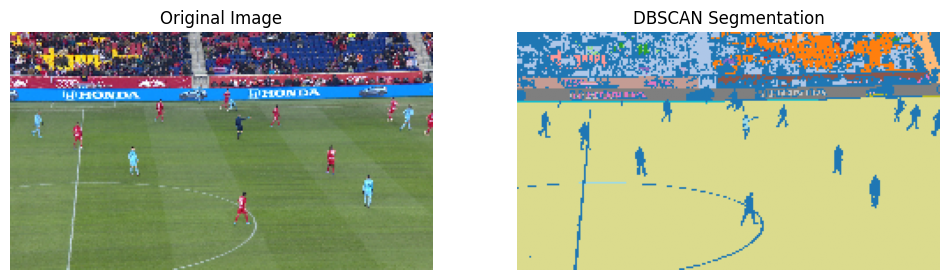

In [10]:
img = images[0]
h, w = img.shape[:2]
y, x = np.indices((h, w))
features = np.column_stack([
    img.reshape(-1, 3).astype(np.float32) / 255.0,
    x.reshape(-1).astype(np.float32) / w,
    y.reshape(-1).astype(np.float32) / h,
])

db = DBSCAN(eps=0.06, min_samples=10)
labels = db.fit_predict(features)

dbscan_label_map = labels.reshape(h, w)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(dbscan_label_map, cmap="tab20")
plt.title("DBSCAN Segmentation")
plt.axis("off")

plt.show()

## 4. Filtering and Merging

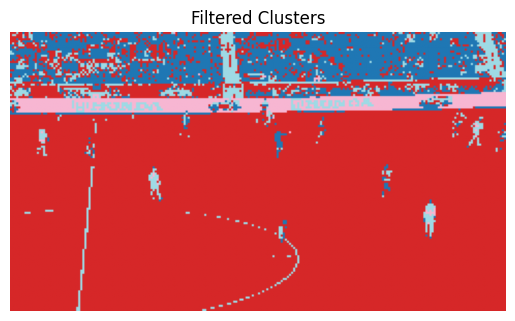

In [13]:
def filter_small_clusters(label_map, min_size=50):
    filtered = np.full_like(label_map, -1)
    for lbl in np.unique(label_map):
        mask = label_map == lbl
        if mask.sum() >= min_size:
            filtered[mask] = lbl
    return filtered

filtered_map = filter_small_clusters(label_map, min_size=8)

plt.imshow(filtered_map, cmap="tab20")
plt.title("Filtered Clusters")
plt.axis("off")
plt.show()

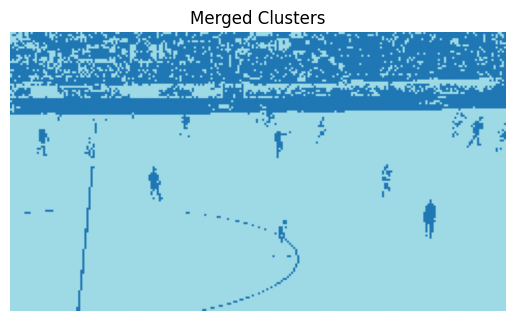

In [15]:
def merge_close_clusters(label_map, iterations=2, min_size=20):
    merged = label_map.copy()
    structure = np.ones((3, 3), dtype=bool)
    labels = [l for l in np.unique(merged) if l != -1]
    sizes = {l: np.sum(merged == l) for l in labels}
    background_label = max(sizes, key=sizes.get)

    for lbl in labels:
        if lbl == background_label:
            continue
        if sizes[lbl] < min_size:
            continue
        mask = merged == lbl
        dilated = ndimage.binary_dilation(mask, structure=structure, iterations=iterations)
        neighbours = np.unique(merged[dilated])
        for n in neighbours:
            if n == -1 or n == lbl or n == background_label:
                continue
            merged[merged == n] = lbl

    return merged

merged_map = merge_close_clusters(filtered_map, iterations=2, min_size=20)

plt.imshow(merged_map, cmap="tab20")
plt.title("Merged Clusters")
plt.axis("off")
plt.show()

## 5. Even More Clustering!

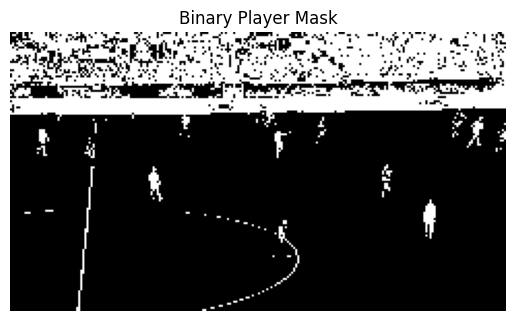

In [16]:
crop_top = int(img.shape[0] * 0.18)
img = img[crop_top:, :, :]

def get_player_mask(label_map):
    labels = [l for l in np.unique(label_map) if l != -1]
    sizes = {l: (label_map == l).sum() for l in labels}
    background_label = max(sizes, key=sizes.get)
    mask = np.logical_and(label_map != background_label, label_map != -1)
    return mask.astype(np.uint8)

player_mask = get_player_mask(merged_map)

plt.imshow(player_mask * 255, cmap="gray")
plt.title("Binary Player Mask")
plt.axis("off")
plt.show()

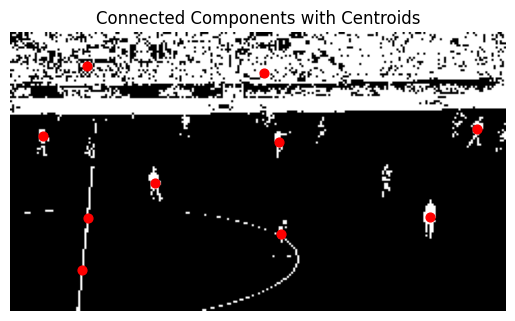

Number of components found: 10


In [17]:
labeled_components, num_components = ndimage.label(player_mask > 0)
sizes = ndimage.sum(player_mask > 0, labeled_components, range(1, num_components + 1))
valid_labels = [i + 1 for i, s in enumerate(sizes) if s >= 15]
centroids = ndimage.center_of_mass(player_mask > 0, labeled_components, valid_labels)

plt.imshow(player_mask > 0, cmap="gray")
for c in centroids:
    if c[0] == c[0]:
        plt.scatter(c[1], c[0], c="red", s=40)
plt.title("Connected Components with Centroids")
plt.axis("off")
plt.show()

print("Number of components found:", len(valid_labels))

## 6. More Advanced Features! (Bonus)

In [19]:
import torch
import torchvision.models as models
import torchvision.transforms as T

resnet = models.resnet18(weights="IMAGENET1K_V1")
resnet_partial = torch.nn.Sequential(*list(resnet.children())[:6])
resnet_partial.eval()

transform = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

import torch.nn.functional as F

def extract_resnet_features(img, output_size):
    tensor = transform(img).unsqueeze(0)
    with torch.no_grad():
        feature_map = resnet_partial(tensor)
    feature_map = F.interpolate(feature_map, size=output_size, mode='bilinear', align_corners=False)
    feature_map = feature_map.squeeze(0).permute(1, 2, 0).numpy()
    h, w, c = feature_map.shape
    return feature_map.reshape(-1, c), h, w

resnet_features, fh, fw = extract_resnet_features(img, output_size=(img.shape[0], img.shape[1]))

print("Feature map size:", fh, fw)

Feature map size: 111 240


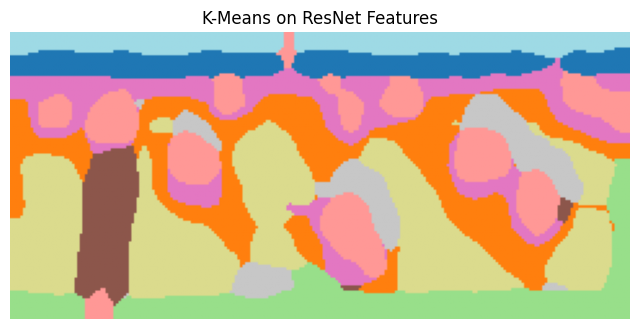

In [26]:
resnet_features_normalized = normalize(resnet_features, norm='l2')
kmeans_resnet = KMeans(n_clusters=k, n_init=5, random_state=42).fit(resnet_features_normalized)
resnet_label_map = kmeans_resnet.labels_.reshape(fh, fw)

plt.figure(figsize=(8, 8))
plt.imshow(resnet_label_map, cmap="tab20")
plt.title("K-Means on ResNet Features")
plt.axis("off")
plt.show()

## 7. Evaluation

In [27]:
def build_gt_mask(coco, file_name, scale):
    image_info = next(im for im in coco["images"] if im["file_name"] == file_name)
    image_id = image_info["id"]
    height, width = image_info["height"], image_info["width"]
    mask = np.zeros((height, width), dtype=np.uint8)
    anns = [a for a in coco["annotations"] if a["image_id"] == image_id]
    for ann in anns:
        for seg in ann["segmentation"]:
            poly = np.array(seg).reshape(-1, 2).astype(np.int32)
            cv2.fillPoly(mask, [poly], 1)
    new_w = int(width * scale)
    new_h = int(height * scale)
    mask = cv2.resize(mask, (new_w, new_h), interpolation=cv2.INTER_NEAREST)
    return mask

def dice_score(pred, gt):
    intersection = np.logical_and(pred, gt).sum()
    return 2 * intersection / (pred.sum() + gt.sum() + 1e-6)

def iou_score(pred, gt):
    intersection = np.logical_and(pred, gt).sum()
    union = np.logical_or(pred, gt).sum()
    return intersection / (union + 1e-6)

In [28]:
dice_scores = []
iou_scores = []

for file_name, img in zip(sample_images_names, images):
    label_map = kmeans_segment(img, best_k)
    filtered_map = filter_small_clusters(label_map)
    merged_map = merge_close_clusters(filtered_map)
    pred_mask = get_player_mask(merged_map)
    gt_mask = build_gt_mask(coco, file_name, scale)
    dice_scores.append(dice_score(pred_mask, gt_mask))
    iou_scores.append(iou_score(pred_mask, gt_mask))

print("Mean Dice score:", np.mean(dice_scores))
print("Mean IoU score:", np.mean(iou_scores))

Mean Dice score: 0.0988137572608313
Mean IoU score: 0.05223328014887732


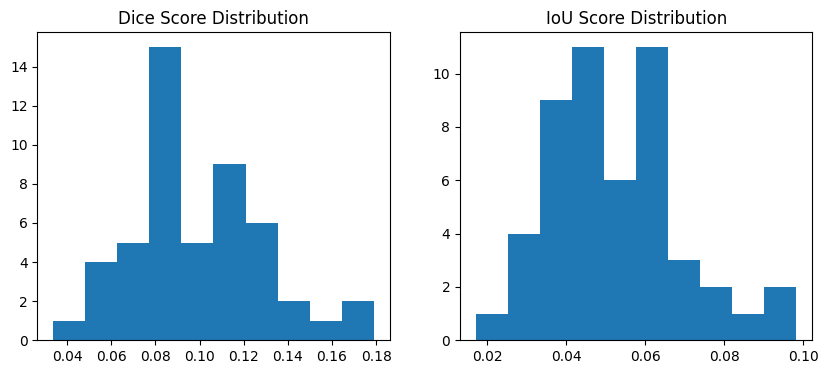

In [29]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.hist(dice_scores, bins=10)
plt.title("Dice Score Distribution")
plt.subplot(1, 2, 2)
plt.hist(iou_scores, bins=10)
plt.title("IoU Score Distribution")
plt.show()